# Laboratorio # 4

- Mathrew Cordero
- Gustavo Cruz
- Pedro Guzmán

Repositorio: https://github.com/donmatthiuz/ModelacionSimu/tree/lab4

In [21]:
import random
import math
import matplotlib.pyplot as plt
def order_crossover(parent1, parent2):
    size = len(parent1)
    child = [None] * size
    start, end = sorted(random.sample(range(size), 2))
    child[start:end] = parent1[start:end]
    p2_index = 0
    for i in range(size):
        if child[i] is None:
            while parent2[p2_index] in child:
                p2_index += 1
            child[i] = parent2[p2_index]

    return child

def mutate(route, mutation_rate=0.1):
    new_route = route[:]
    if random.random() < mutation_rate:
        if random.random() < 0.5:
            i, j = random.sample(range(len(route)), 2)
            new_route[i], new_route[j] = new_route[j], new_route[i]
        else:
            i, j = sorted(random.sample(range(len(route)), 2))
            new_route[i:j] = reversed(new_route[i:j])
    return new_route

In [22]:
def create_individual(num_cities):
    route = list(range(num_cities))
    random.shuffle(route)
    return route

def create_population(pop_size, num_cities):
    return [create_individual(num_cities) for _ in range(pop_size)]

def total_distance(route, coords=None, dist_matrix=None):
    distance = 0
    for i in range(len(route)):
        a, b = route[i], route[(i+1) % len(route)]
        if coords:
            x1, y1 = coords[a]
            x2, y2 = coords[b]
            distance += math.hypot(x2 - x1, y2 - y1)
        elif dist_matrix:
            distance += dist_matrix[a][b]
    return distance

def tournament_selection(population, fitnesses, k=3):
    selected = random.sample(list(zip(population, fitnesses)), k)
    selected.sort(key=lambda x: x[1])
    return selected[0][0]

def next_generation(population, fitnesses, mutation_rate=0.1):
    new_population = []
    pop_size = len(population)
    
    while len(new_population) < pop_size:
        parent1 = tournament_selection(population, fitnesses)
        parent2 = tournament_selection(population, fitnesses)
        
        child = order_crossover(parent1, parent2)
        child = mutate(child, mutation_rate)
        
        new_population.append(child)
    
    return new_population



In [23]:
def genetic_algorithm(num_cities, coords=None, dist_matrix=None, N=50, maxIter=500, mutation_rate=0.1):
    population = create_population(N, num_cities)
    best_route, best_distance = None, float('inf')
    
    for iteration in range(maxIter):
        fitnesses = [total_distance(route, coords, dist_matrix) for route in population]
        
        # La mejor ruta es obtenda dela generacion por eso ponemos min
        min_idx = fitnesses.index(min(fitnesses))
        if fitnesses[min_idx] < best_distance:
            best_distance = fitnesses[min_idx]
            best_route = population[min_idx]
        
        # Nueva generación
        population = next_generation(population, fitnesses, mutation_rate)
        
        if iteration % 50 == 0:
            print(f"Iteración {iteration}: mejor distancia = {best_distance:.2f}")
    
    return best_route, best_distance


### Ejemplo

In [ ]:
import math
import random

dist_matrix = [
    [0, 2, 9, 10, 7],
    [1, 0, 6, 4, 3],
    [15, 7, 0, 8, 3],
    [6, 3, 12, 0, 5],
    [10, 4, 8, 5, 0]
]

num_cities = len(dist_matrix)

best_route, best_distance = genetic_algorithm(
    num_cities=num_cities,
    dist_matrix=dist_matrix,
    N=20,           # tamaño de población
    maxIter=200,    # número de generaciones
    mutation_rate=0.2
)

print("\nMejor ruta encontrada:", best_route)
print("Distancia total:", best_distance)


Iteración 0: mejor distancia = 22.00
Iteración 50: mejor distancia = 21.00
Iteración 100: mejor distancia = 21.00
Iteración 150: mejor distancia = 21.00

Mejor ruta encontrada: [3, 1, 0, 2, 4]
Distancia total: 21


## Problema 2

Resolviendo TSP de Berlin52 con 52 ciudades...
Usando algoritmo genético con los siguientes parámetros:
- Tamaño de población: 100
- Generaciones máximas: 1000
- Tasa de mutación: 0.15
- Selección por torneo (k=3)

Ejecutando...
Iteración 0: mejor distancia = 25798.67
Iteración 50: mejor distancia = 15035.91
Iteración 100: mejor distancia = 12236.94
Iteración 150: mejor distancia = 11137.31
Iteración 200: mejor distancia = 10286.37
Iteración 250: mejor distancia = 9758.86
Iteración 300: mejor distancia = 8908.95
Iteración 350: mejor distancia = 8439.91
Iteración 400: mejor distancia = 8141.15
Iteración 450: mejor distancia = 8141.15
Iteración 500: mejor distancia = 8129.20
Iteración 550: mejor distancia = 8129.20
Iteración 600: mejor distancia = 8129.20
Iteración 650: mejor distancia = 8073.43
Iteración 700: mejor distancia = 8073.43
Iteración 750: mejor distancia = 8073.43
Iteración 800: mejor distancia = 8064.58
Iteración 850: mejor distancia = 7997.72
Iteración 900: mejor distancia 

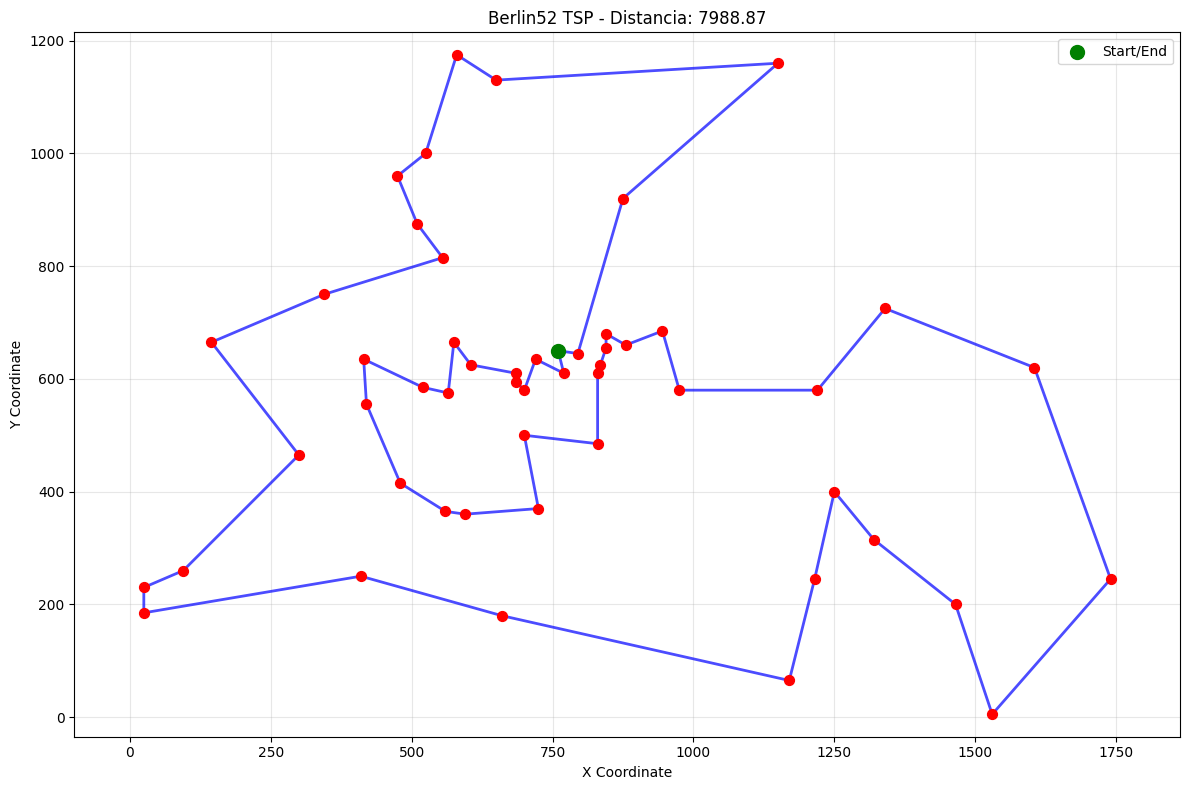

In [27]:
def parse_berlin52_data():
    berlin52_data = """1 565.0 575.0
2 25.0 185.0
3 345.0 750.0
4 945.0 685.0
5 845.0 655.0
6 880.0 660.0
7 25.0 230.0
8 525.0 1000.0
9 580.0 1175.0
10 650.0 1130.0
11 1605.0 620.0 
12 1220.0 580.0
13 1465.0 200.0
14 1530.0 5.0
15 845.0 680.0
16 725.0 370.0
17 145.0 665.0
18 415.0 635.0
19 510.0 875.0  
20 560.0 365.0
21 300.0 465.0
22 520.0 585.0
23 480.0 415.0
24 835.0 625.0
25 975.0 580.0
26 1215.0 245.0
27 1320.0 315.0
28 1250.0 400.0
29 660.0 180.0
30 410.0 250.0
31 420.0 555.0
32 575.0 665.0
33 1150.0 1160.0
34 700.0 580.0
35 685.0 595.0
36 685.0 610.0
37 770.0 610.0
38 795.0 645.0
39 720.0 635.0
40 760.0 650.0
41 475.0 960.0
42 95.0 260.0
43 875.0 920.0
44 700.0 500.0
45 555.0 815.0
46 830.0 485.0
47 1170.0 65.0
48 830.0 610.0
49 605.0 625.0
50 595.0 360.0
51 1340.0 725.0
52 1740.0 245.0"""
    
    coords = {}
    for line in berlin52_data.strip().split('\n'):
        parts = line.strip().split()
        city_id = int(parts[0]) - 1  
        x, y = float(parts[1]), float(parts[2])
        coords[city_id] = (x, y)
    
    return coords

def plot_route(coords, route, title="TSP Route"):
    plt.figure(figsize=(12, 8))
    
    x_coords = [coords[city][0] for city in route] + [coords[route[0]][0]]
    y_coords = [coords[city][1] for city in route] + [coords[route[0]][1]]
    
    plt.plot(x_coords, y_coords, 'b-', linewidth=2, alpha=0.7)
    plt.scatter(x_coords[:-1], y_coords[:-1], c='red', s=50, zorder=5)
    
    plt.scatter(coords[route[0]][0], coords[route[0]][1], c='green', s=100, zorder=10, label='Start/End')
    
    plt.title(title)
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

def plot_convergence(distance_history):
    plt.figure(figsize=(10, 6))
    plt.plot(distance_history, 'b-', linewidth=2)
    plt.title('Convergencia del Algoritmo Genético')
    plt.xlabel('Generación')
    plt.ylabel('Mejor Distancia')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def run_berlin52_tsp():
    """Run the Berlin52 TSP solver"""
    random.seed(42)
    
    coords = parse_berlin52_data()
    num_cities = len(coords)
    
    print(f"Resolviendo TSP de Berlin52 con {num_cities} ciudades...")
    print("Usando algoritmo genético con los siguientes parámetros:")
    print("- Tamaño de población: 100")
    print("- Generaciones máximas: 1000")
    print("- Tasa de mutación: 0.15")
    print("- Selección por torneo (k=3)")
    print("\nEjecutando...")
    
    best_route, best_distance = genetic_algorithm(
        num_cities=num_cities,
        coords=coords,
        N=100,              # población más grande
        maxIter=1000,       # más generaciones
        mutation_rate=0.15  # tasa de mutación ajustada
    )
    
    print(f"\n=== RESULTADOS ===")
    print(f"Mejor distancia encontrada: {best_distance:.2f}")
    print(f"Mejor ruta (primeras 10 ciudades): {best_route[:10]}...")
    print(f"Ruta completa: {best_route}")
    

    plot_route(coords, best_route, f"Berlin52 TSP - Distancia: {best_distance:.2f}")
    
    
    return best_route, best_distance, coords

run_berlin52_tsp();
    